In [1]:
! pip install pretty_midi numpy matplotlib seaborn

In [2]:
import pretty_midi
import numpy as np
import csv
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ドラムのMIDIノート番号
DRUM_MAP = {
    36: "Kick",
    38: "Snare(Head)",
    40: "Snare(Rim)",
    37: "Snare X-Stick",
    48: "Tom_1",
    50: "Tom_1(Rim)",
    45: "Tom_2",
    47: "Tom_2(Rim)",
    43: "Tom_3(Head)",
    58: "Tom_3(Rim)",
    46: "HH_Open(Bow)",
    26: "HH_Open(Edge)",
    42: "HH_Closed(Bow)",
    22: "HH_Closed(Edge)",
    44: "HH_Pedal",
    49: "Crash_1(Bow)",
    55: "Crash_1(Edge)",
    57: "Crash_2(Bow)",
    52: "Crash_2(Edge)",
    51: "Ride(Bow)",
    59: "Ride(Edge)",
    53: "Ride(Bell)"
}

DRUM_NOTES = list(DRUM_MAP.keys())
NUM_DRUMS = len(DRUM_NOTES)
DRUM_LABELS = [DRUM_MAP[pitch] for pitch in DRUM_NOTES]

In [4]:
def midi_to_onehot(midi_path, note_value):
    """
    midi_path : MIDIファイルのパス
    note_value : 何分音符で区切るか
                 4  = 4分音符
                 8  = 8分音符
                 16 = 16分音符
    """

    midi_data = pretty_midi.PrettyMIDI(midi_path)

    # テンポ取得（最初のテンポを使用）
    tempo = midi_data.get_tempo_changes()[1][0]  # BPM

    # 1拍（4分音符）の秒数
    quarter_note_sec = 60.0 / tempo

    # 指定分音符の秒数
    resolution = quarter_note_sec * (4.0 / note_value)

    # ドラムトラック取得
    drum_tracks = [inst for inst in midi_data.instruments if inst.is_drum]
    if len(drum_tracks) == 0:
        raise ValueError("ドラムトラックが見つかりません")

    # 曲の長さ
    end_time = midi_data.get_end_time()
    time_steps = int(np.ceil(end_time / resolution))

    # one-hot配列 (time_steps × NUM_DRUMS)
    onehot = np.zeros((time_steps, NUM_DRUMS), dtype=np.int32)

    for drum in drum_tracks:
        for note in drum.notes:
            if note.pitch in DRUM_NOTES:
                time_index = int(note.start / resolution)
                drum_index = DRUM_NOTES.index(note.pitch)
                if time_index < time_steps:
                    onehot[time_index, drum_index] = 1

    return onehot

In [9]:
!mkdir -p onehot_data

In [ ]:
# 全てのmidiファイルをonehot表現のnumpy配列に変換 -> onehot_dataディレクトリ下に保存

with open("./info.csv", "r", encoding="ms932") as csv_file:
    
    #辞書形式でcsvファイルを読み込み
    f = csv.DictReader(csv_file, delimiter=",", doublequote=True, lineterminator="\r\n", quotechar='"', skipinitialspace=True)

    marker = 0
    
    for row in f:
        midi_path = row['midi_filename']
        onehot = midi_to_onehot(midi_path, note_value=16)

        save_path = f"./onehot_data/{marker}.npy"
        print(save_path)
        np.save(save_path, onehot)
        
        marker += 1

[[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


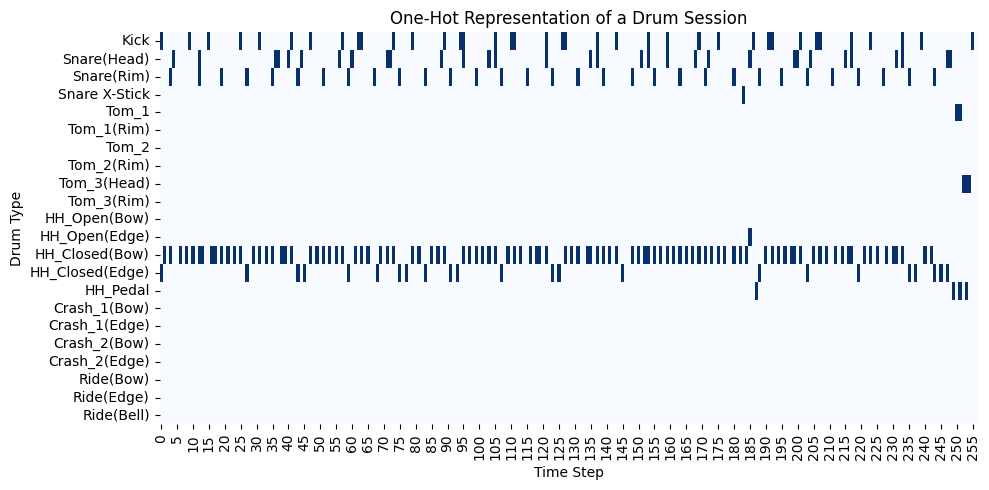

In [16]:
# onehot表現の可視化
onehot = np.load('./onehot_data/1.npy')
print(onehot)

plt.figure(figsize=(10, 5))
sns.heatmap(
    onehot.T,
    cmap="Blues",
    cbar=False,
    yticklabels=DRUM_LABELS
)
plt.xlabel("Time Step")
plt.ylabel("Drum Type")
plt.title("One-Hot Representation of a Drum Session")
plt.xticks(rotation=90)  # ラベルを縦表示
plt.tight_layout()
# plt.savefig("Drum_One-Hot_Matrix_Heatmap.png")
plt.show()